# Widzenie komputerowe - Laboratoria nr 12

## Opis laboratoriów

- zapoznanie z popularnymi zbiorami danych,
- zapoznanie z repozytoriami zbiorów danych,
- zapoznanie z popularnymi modelami neuronowymi,
- zapoznanie z repozytoriami modeli neuronowych

## Funkcje pomocnicze

### Niezbędne biblioteki


In [ ]:
!pip uninstall -y tensorflow tensorflow_hub numpy tensorflow-model-optimization

Found existing installation: tensorflow 2.18.0
Uninstalling tensorflow-2.18.0:
  Successfully uninstalled tensorflow-2.18.0
Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
Found existing installation: tensorflow-model-optimization 0.8.0
Uninstalling tensorflow-model-optimization-0.8.0:
  Successfully uninstalled tensorflow-model-optimization-0.8.0


In [ ]:
!pip install -q tensorflow==2.18.0
!pip install -q tfds-nightly
!pip install -q tensorflow-model-optimization

# ok, dobra, próbowałem, ale jedna paczka wymaga numpy <1.2.coś
# inna >2. ale <2.8
# no i coś z potrzebą latest numpy, oczywiście

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds
import tensorflow_hub as hub
import numpy as np
import cv2
import PIL

from pprint import pprint

ModuleNotFoundError: No module named 'tensorflow_hub'

In [ ]:
!wget -O lena_std.tif http://www.lenna.org/lena_std.tif
!wget -O graf.png https://github.com/opencv/opencv/raw/master/samples/data/graf1.png

### Wizualizacja



Skrypt do wyżwietlania obrazów BGR oraz Grayscale.

In [ ]:
def imshow(a):
  a = a.clip(0, 255).astype('uint8')
  if a.ndim == 3:
    if a.shape[2] == 4:
      a = cv2.cvtColor(a, cv2.COLOR_BGRA2RGBA)
    else:
      a = cv2.cvtColor(a, cv2.COLOR_BGR2RGB)
  display(PIL.Image.fromarray(a))

# Zbiory danych

Najważniejszym narzędziem podczas prowadzenia prac zarówno badawczo-rozwojowych jak i deweloperskich jest dobrze zdefiniowany zbiór danych. Modele neuronowe są bardzo czułe na wszelkie niespójności oraz wady zawarte w danych, dlatego takie zbiory danych jak MNIST czy CIFAR są wciąż bardzo popularne.

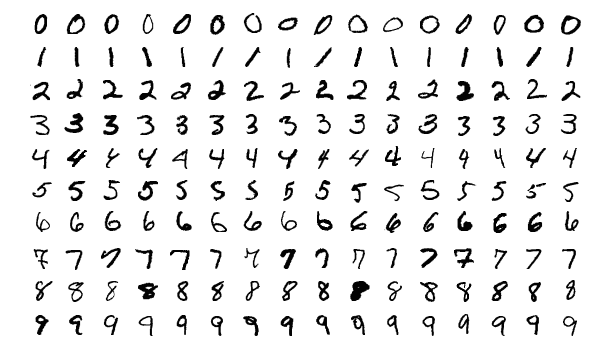

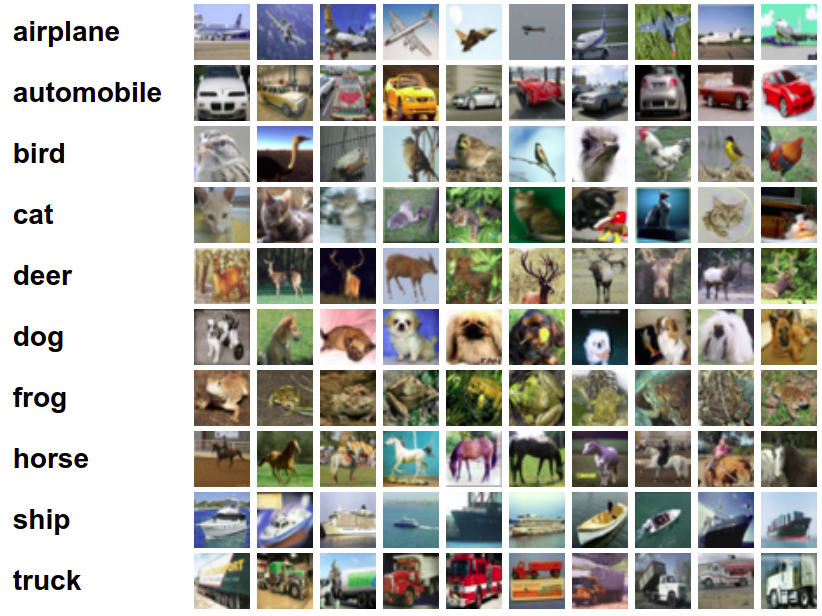

Mimo ich prostoty, zbiory te są bardzo dobrze zdefiniowane, zarówno pod względem liczebności danych jak i ich formatu. Co więcej, autorzy zadbali również o liczebność i zróżnicowanie danych względem każdej z klasy danych osobno.

**Powyższe dane bardzo często stosuje się do prototypowania modeli neuronowych lub podczas prac bazowych, dotyczących nowych zagadnień ale również do weryfikacji założeń badawczych.**

Pomimo olbrzymiej przydatności tych zbiorów danych zaistniała potrzeba na nowe, bardziej wyrafinowane i skomplikowane dane. Dane, dzięki którym możliwe będzie rozwiązanie kolejnych problemów naukowych. Ponieważ możliwości sieci neuronowych wraz z połączeniem wysokiej wydajności sprzętowej (np. GPU i TPU) pozwalają osiągać wyniki deklasujące poprzednie rozwiązania w większości dziedzin informatycznych ich popularność gwałtownie wzrosła. Wraz z popularnością na sieci neuronowe wzrósł popyt na zbiory danych i obecnie możemy zauważyć trend polegający na prześciganiu się zarówno uniwersytetów jak i firm prywatnych czy instytucji państwowych w przytotowywaniu własnych zbiorów danych, które następnie są udostępniane społeczności akademickiej (zazwyczaj za darmo).

Ze względu na olbrzymie zainteresowanie zbiorami danych powstało wiele prób zunifikowania dostępu do nich. W dostępie do danych przoduje firma Google, która wykorzystuje możliwości przechowywania i przetwarzania masywnych danych na swoich serwerach. Dodatkowo, posiadając najpopularniejszą wyszukiwarkę informacji na świecie z łatwością może zbierać i przytotowywać kolejne zbiory danych.

Do ważniejszych repozytoriów danych obecnie należą:
- **TensorFlow Datasets** - platforma udostępniona przez Google zawierająca bibliotekę w Pythonie dostosowaną do formatu przetwarzania obecnego w bibliotece TensorFlow. Biblioteka łączy się z repozytoriami na serwerach Google i pozwala na automatyczne pobieranie danych do środowiska lokalnego. Platforma TensorFlow Datasets pozwala również na publikowanie własnych zbiorów danych.
- **Google Research Datasets** - zestaw i opracowanie popularnych zbiórów danych. Jest to jedynie strona, na której zostały zaprezentowane najczęściej wykorzystywane zbiory danych przez środowisko akademickie.
- **Google Dataset Search** - systematyczne podejście do poszukiwania danych zaprezentowane przez firmę Google. Jest to wyszukiwarka zbiorów na podstawie słów kluczowych, która przeszukuje różne repozytoria w celu znalezienia odpowiednich danych.
- usługi cloudowe - ze względu na popularyzację przetwarzania w chmurze, firmy dostarczające tę funkcjonalność pozwalają (lub same przygotowują) zbiory danych juz dostępne w usłudze cloudowej. Do popularniejszych należą **[Open Data on AWS](https://registry.opendata.aws/)**, **[Google Cloud Platform](https://console.cloud.google.com/marketplace/browse?filter=solution-type:dataset&pli=1)** i **[Azure Open Datasets](https://azure.microsoft.com/pl-pl/services/open-datasets/)**.

## TensorFlow Datasets

TensorFlow Datasets jest to biblioteka historycznie wydzielona z bilbioteki TensorFlow, która zawiera API dotyczące pobierania i przetwarzania zbiorów danych. Biblioteka zawiera implementacje pozwalającą na pobieranie gotowych zbiorów danych.

[Lista obecnie dostępnych zbiorów.](https://www.tensorflow.org/datasets/catalog/overview)

In [ ]:
tfds.list_builders()

Biblioteka posiada wiele różnych interfejsów pozwalających na pobranie zbiorów danych.

Za pomocą command line:

In [ ]:
!tfds build mnist
!tfds build cifar10

Za pomocą funkcji pomocniczej **tfds.load**:

In [ ]:
train_ds_mnist = tfds.load('mnist', split='train', shuffle_files=True)

print(train_ds_mnist)

In [ ]:
_train_ds_mnist = train_ds_mnist \
  .shuffle(1024) \
  .batch(32) \
  .prefetch(4)

data = next(iter(_train_ds_mnist))

print(data['image'].shape, data['label'].shape)

In [ ]:
images = data['image'].numpy()

imshow(np.concatenate(images, 1))

''Ręcznie'' korzystając z funkcjonalności bilbioteki - **builder**.

In [ ]:
builder = tfds.builder('mnist')
builder.download_and_prepare()

train_ds_mnist = builder.as_dataset(split='train', shuffle_files=True)

print(train_ds_mnist)

In [ ]:
_train_ds_mnist = train_ds_mnist \
  .shuffle(1024) \
  .batch(32) \
  .prefetch(4)

data = next(iter(_train_ds_mnist))

print(data['image'].shape, data['label'].shape)

In [ ]:
images = data['image'].numpy()

imshow(np.concatenate(images, 1))

### Funkcje pomocnicze

Biblioteka TFDS zawiera również funkcje pomocnicz pozwalające na analizę i wyświetlanie danych.

In [ ]:
train_ds_mnist, info = tfds.load('mnist', split='train', with_info=True)

print(info)

In [ ]:
fig = tfds.show_examples(train_ds_mnist, info)

In [ ]:
tfds.as_dataframe(train_ds_mnist.take(4), info)

# Modele

Codziennie publikowane są artykuły opisujące nowe architektury neuronowe lub ich usprawnienia. Dodatkowo, modele neuronowe są zazwyczaj tworzone przez społeczność akademicką, a charakterystyka modeli często nie pozwala na unifikację ich zapisu. Powoduje to problem z udostępnianiem modeli (a nawet i weryfikacją wyników).



## TensorFlow Hub

Jednym z rozwiązań jest sprowadzenie modelu neuronowego do tej samej postaci, która może być przetwarzana przez jedno API. Korzystając z TensorFlow możliwa jest transformacja modelu przetwarzania do tzn. Graph API. Jest to graf zależności pomiędzy zdefiniowanymi operacjami (dodawanie, mnożenie, itp.), który może być następnie zoptymalizowany oraz, co jest bardzo ważne, model taki jest niezależny od wcześniejszej implementacji (t.j. postać symboliczna, np. w Keraz, transformowana jest do postaci grafu zależności). Tak utworzony model można z łatwością przechowywać, zachowując informację jedynie o interfejsie wejścia i wyjścia.

Podobnie jak w przypadku zbiorów danych, Google stworzyło platformę na której można udostępniać swoje modele (pretrenowane!). Platforma [TensorFlow Hub](https://tfhub.dev/) pozwala na łatwe pobranie istniejących już modeli i ponowne ich wykorzystanie.

In [ ]:
lena = cv2.imread('./lena_std.tif', cv2.IMREAD_COLOR)
imshow(lena)

In [ ]:
graf = cv2.imread('./graf.png', cv2.IMREAD_COLOR)
imshow(graf)

In [ ]:
hub_module = hub.load('https://tfhub.dev/google/magenta/arbitrary-image-stylization-v1-256/2')
print(hub_module)

In [ ]:
print(len(hub_module.variables), '\n', hub_module.variables[0])

In [ ]:
lena_tf = tf.constant(lena.astype(np.float32)[np.newaxis, ...] / 255.)
graf_tf = tf.constant(graf.astype(np.float32)[np.newaxis, ...] / 255.)

graf_tf = tf.image.resize(graf_tf, (256, 256))

print(lena_tf.shape, graf_tf.shape)


In [ ]:
lena_stylized = hub_module(lena_tf, graf_tf)[0][0].numpy()
imshow(lena_stylized * 255)

## TensorFlow Model Garden

Innym rozwiązaniem jest wykorzystanie gotowych implementacji innych autorów. Oprócz przeszukiwania referencji do publicznych repozytoriów zawartych w artykułach naukowych lub blogach programistycznych można również spojrzeć na oficjalne repozytorium biblioteki TensorFlow.

Można w niej znaleźć implementacje popularnych modeli neuronowych wraz z instrukcją dotyczącą odtworzenia wyników z artykułów. Podrepozytorium biblioteki TensorFlow nazywa się [TensorFlow Model Garden](https://github.com/tensorflow/models).

W skład repozytorium wchodzą zarówno oficjalne implementacje modeli jak i te, które są wciąż rozwijane w ramach badań naukowych.

Wśród oficjalnych i przetestowanych implementacji znajdziemy 3 główne gałęzie modeli:
- **wizyjne**,
- przetwarzania języka naturalnego,
- rekomendacyjne

In [ ]:
!git clone https://github.com/tensorflow/models.git

In [ ]:
import os
os.environ['PYTHONPATH'] += ":/content/models"

In [ ]:
!python3 /content/models/official/vision/image_classification/mnist_main.py \
  --model_dir=/content/results/mnist \
  --data_dir=/content/data/mnist \
  --train_epochs=10 \
  --distribution_strategy=one_device \
  --num_gpus=1 \
  --download

# Zadanie 1

Korzystając z TensorFlow Datasets oraz TensorFlow Hub zaprezentuj działanie dowolnie wybranej sieci neuronowej na danym zbiorze danych. W szczególności:
- wykorzystaj inny zbiór danych niż dotychczas poznane na zajęciach (nie korzystaj z takich zbiorów jak mnist, cifar, caltech),
- przedstaw dane wejściowe korzystając z funkcji pomicniczych tfds lub ręcznie (pokazać kilka przykładów wejście - wyjście),
- pobierz odpowiedni model z TensorFlow Hub (odpowiedni oznacza, że inferencja modelu powinna działać dla wybranego zbioru danych; **uwaga: inferencja nie musi być poprawna w sensie weryfikacji wyników, choć warto wybrać model, który będzie działał dla danego zbioru danych**),
- zaprezentuj wyniki działania modelu na paru próbkach ze zbioru danych (np. dla detekcji obiektów załadować pare losowych obrazów, wykonać inferencję modelu i zaprezentować wyniki detekcji),

In [1]:
# !pip install torch torchvision transformers datasets
# !pip install torch kaggle torchvision matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 49.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 93.6 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [3]:
# !kaggle competitions download -c dogs-vs-cats
# !unzip -q dogs-vs-cats.zip
# !unzip -q train.zip -d data/train
# dobra, jakieś env, nie chce mi się chyba walczyć z kaggle api

Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 4, in <module>
    from kaggle.cli import main
  File "/usr/local/lib/python3.11/dist-packages/kaggle/__init__.py", line 6, in <module>
    api.authenticate()
  File "/usr/local/lib/python3.11/dist-packages/kaggle/api/kaggle_api_extended.py", line 434, in authenticate
    raise IOError('Could not find {}. Make sure it\'s located in'
OSError: Could not find kaggle.json. Make sure it's located in /root/.config/kaggle. Or use the environment method. See setup instructions at https://github.com/Kaggle/kaggle-api/
unzip:  cannot find or open dogs-vs-cats.zip, dogs-vs-cats.zip.zip or dogs-vs-cats.zip.ZIP.
unzip:  cannot find or open train.zip, train.zip.zip or train.zip.ZIP.


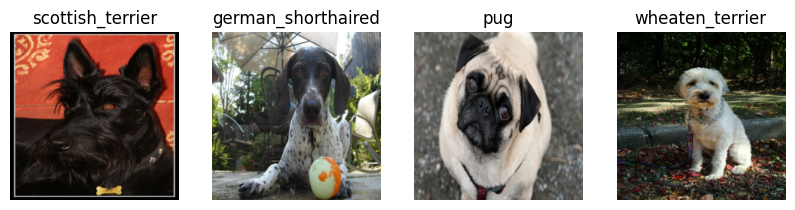

In [13]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os

# Transformacje – resize + tensor
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# Wczytanie zbioru Oxford-IIIT Pet
dataset = datasets.OxfordIIITPet(root='.', download=True, transform=transform)

# Loader
loader = DataLoader(dataset, batch_size=4, shuffle=True)


def get_label_to_breed_map():
    label_to_breed = {}
    breed_to_label = {}
    with open('oxford-iiit-pet/annotations/list.txt', 'r') as f:
        lines = f.readlines()[6:]  # Pierwsze 6 linii to komentarze
        for idx, line in enumerate(lines):
            name = line.split()[0]
            breed = name.rsplit('_', 1)[0]  # np. "Abyssinian_34" → "abyssinian" # koty są z dużej, psy z małej
            if breed not in breed_to_label:
                label = len(breed_to_label)
                breed_to_label[breed] = label
                label_to_breed[label] = breed
    return label_to_breed


# Przykładowa wizualizacja
label_to_breed = get_label_to_breed_map()


images, labels = next(iter(loader))
plt.figure(figsize=(10, 5))
for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(images[i].permute(1, 2, 0))
    label = labels[i].item()
    plt.title(label_to_breed[label])
    plt.axis('off')
plt.show()

# moment, ten zbiór chyyyba już był, nie chce się powtarzać, to ten, em, mno.. samoloty?

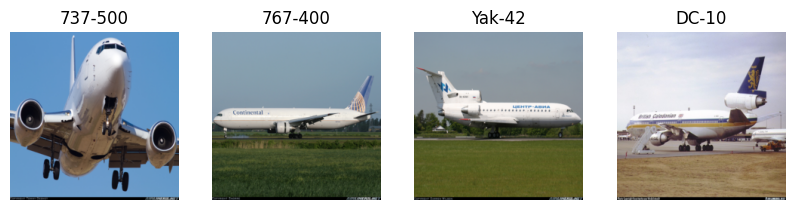

In [20]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os

# Transformacje - resize + tensor
target_size = (224, 224)
transform = transforms.Compose([
    transforms.Resize(target_size),
    transforms.ToTensor()
])

# Wczytanie zbioru FGVCAircraft
dataset = datasets.FGVCAircraft(root='.', download=True, transform=transform)
loader = DataLoader(dataset, batch_size=4, shuffle=True)

# Mapa etykiet (int -> nazwa samolotu)
classes = dataset.classes  # lista etykiet jako stringi, np. ['A330-200', 'A340-600', ...]

# Przykładowa wizualizacja
images, labels = next(iter(loader))
plt.figure(figsize=(10, 5))
for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(images[i].permute(1, 2, 0))
    label = labels[i].item()
    plt.title(classes[label])
    plt.axis('off')
plt.show()

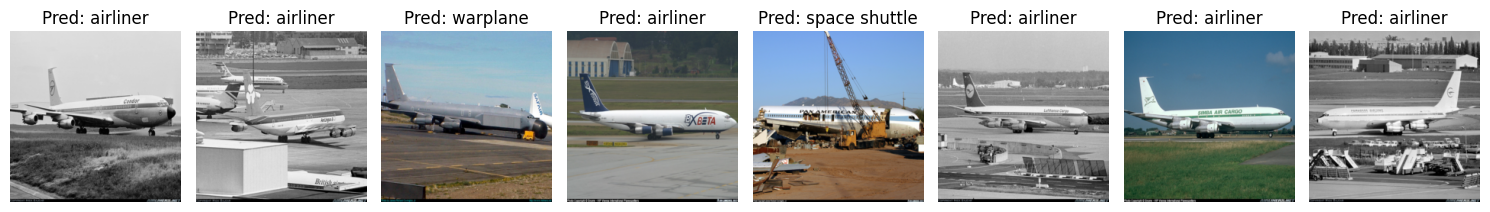

In [21]:
import torch
import torchvision.transforms as transforms
import torchvision.models as models
import torchvision
from PIL import Image
import matplotlib.pyplot as plt
import json
import requests

# Pobierz pretrenowany model z PyTorch Hub
model = models.resnet18(pretrained=True) #wytrenowany ImageNet
model.eval()

# Normalizacja jak dla ImageNet
imagenet_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Wczytaj etykiety klas ImageNet (numer → nazwa)
response = requests.get("https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt")
imagenet_labels = response.text.strip().split('\n')

# Wybierz kilka obrazów ze zbioru
num_images = 8
fig, axs = plt.subplots(1, num_images, figsize=(15, 5))

for i in range(num_images):
    image, _ = dataset[i]  # z oryginalnego zbioru
    img_tensor = imagenet_transform(transforms.ToPILImage()(image)).unsqueeze(0)  # [1, 3, 224, 224]

    # Inference
    with torch.no_grad():
        outputs = model(img_tensor)
        _, predicted = outputs.max(1)
        label = imagenet_labels[predicted.item()]

    # Wyświetlenie
    axs[i].imshow(image.permute(1, 2, 0))
    axs[i].set_title(f'Pred: {label}')
    axs[i].axis('off')

plt.tight_layout()
plt.show()

# to jest próbka z danych ze zbioru

Saving avatar-kot-loading.png to avatar-kot-loading (1).png
Saving kot1.png to kot1.png
Saving kotpanik.jpg to kotpanik.jpg
Saving yass.png to yass (1).png


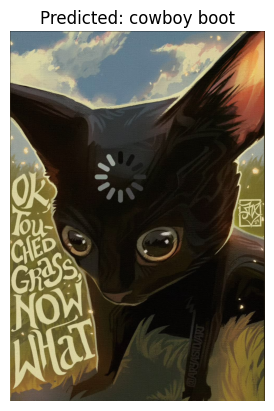

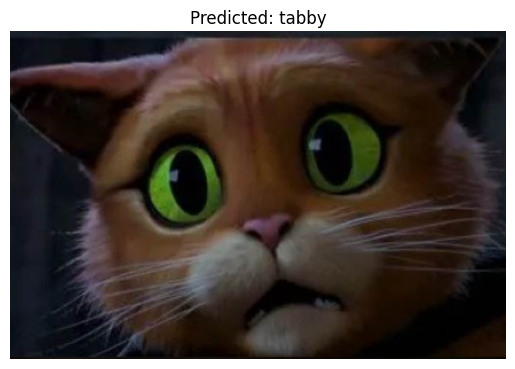

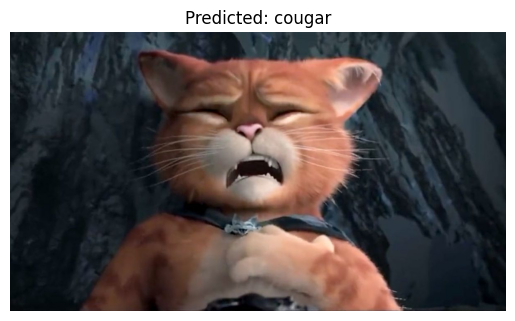

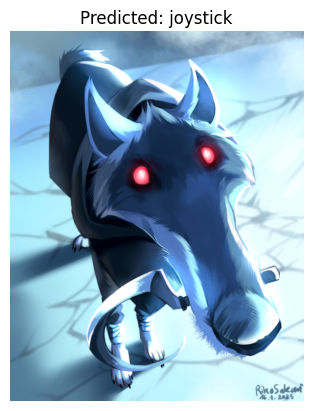

In [25]:
# to jest własna próbka
from google.colab import files
from PIL import Image
import torch
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
import requests

# Załaduj etykiety klas z ImageNet
response = requests.get("https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt")
imagenet_labels = response.text.strip().split('\n')

# Załaduj model ResNet18
model = models.resnet18(pretrained=True)
model.eval()

# Transformacje zgodne z ImageNet
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Wybierz plik
uploaded = files.upload()

for filename in uploaded.keys():
    # Otwórz obraz i przekształć go
    image = Image.open(filename).convert('RGB')
    input_tensor = transform(image).unsqueeze(0)

    # Inference
    with torch.no_grad():
        output = model(input_tensor)
        _, predicted = output.max(1)
        predicted_label = imagenet_labels[predicted.item()]

    # Wyświetl obraz z predykcją
    plt.imshow(image)
    plt.title(f'Predicted: {predicted_label}')
    plt.axis('off')
    plt.show()

# no na rysunkach i animacjach raczej model średnio działa, ale na rzeczywistych zdjęciach był świetny

# Zadanie 2 (dodatkowe) ***

Podobnie jak w zadaniu 1 wybierz zbiór danych oraz model dostępny w TensorFlow Hub i przeprowadź operacje **douczania** modelu na tych danych.

Przykładowy schemat działania rozwiązania:
- pobranie danych wizyjnych do klasyfikacji,
- pobranie modelu do **embeddingu obrazów** (tzw. feature vector),
- utworzenie modelu który pobiera feature vectors i wykonuje klasyfikację,
- wykonanie pętli uczenia dla nowo utworzonego modelu

In [ ]:
# tym razem chyba odpuszzcam dodatkowe, wystarczy mi :")